<a href="https://colab.research.google.com/github/NeonLabs146/Neural-network/blob/main/k_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering from Scratch
A simple K-Means implementation tested on synthetic blob data.

In [90]:
import random
import numpy as np


class KMeans:
    def __init__(self, n_clusters, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X, cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break
        return cluster_group

    def assign_clusters(self, X):
        cluster_group = []
        distances = []
        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row - centroid, row - centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()
        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []
        cluster_type = np.unique(cluster_group)
        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))
        return np.array(new_centroids)

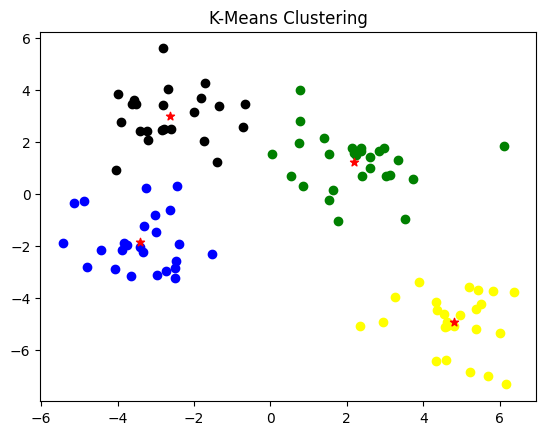

In [112]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

centroids = [(-3, -2), (5, -5), (-2.5, 3), (2, 1)]
cluster_std = [1, 1, 1, 1]
X, Y = make_blobs(
    n_samples=100,
    cluster_std=cluster_std,
    centers=centroids,
    n_features=2,
    random_state=2,
)

# import data and test
# df = pd.read_csv('student_clustering.csv')
# X = df.iloc[:,:].values

km = KMeans(n_clusters=4, max_iter=10)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], color='black')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], color='blue')
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], color='green')
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], color='yellow')
plt.scatter(km.centroids[:, 0], km.centroids[:, 1], color='red', marker='*')
plt.title('K-Means Clustering')
plt.show()